# Daisyworld: параметры и численность

Четыре базовые комбинации, по 1000 шагов на каждую.

## Окружение и модель

In [1]:
using DrWatson
@quickactivate "project"
include(srcdir("experiments.jl"))

savehistory (generic function with 1 method)

## Независимые прогоны

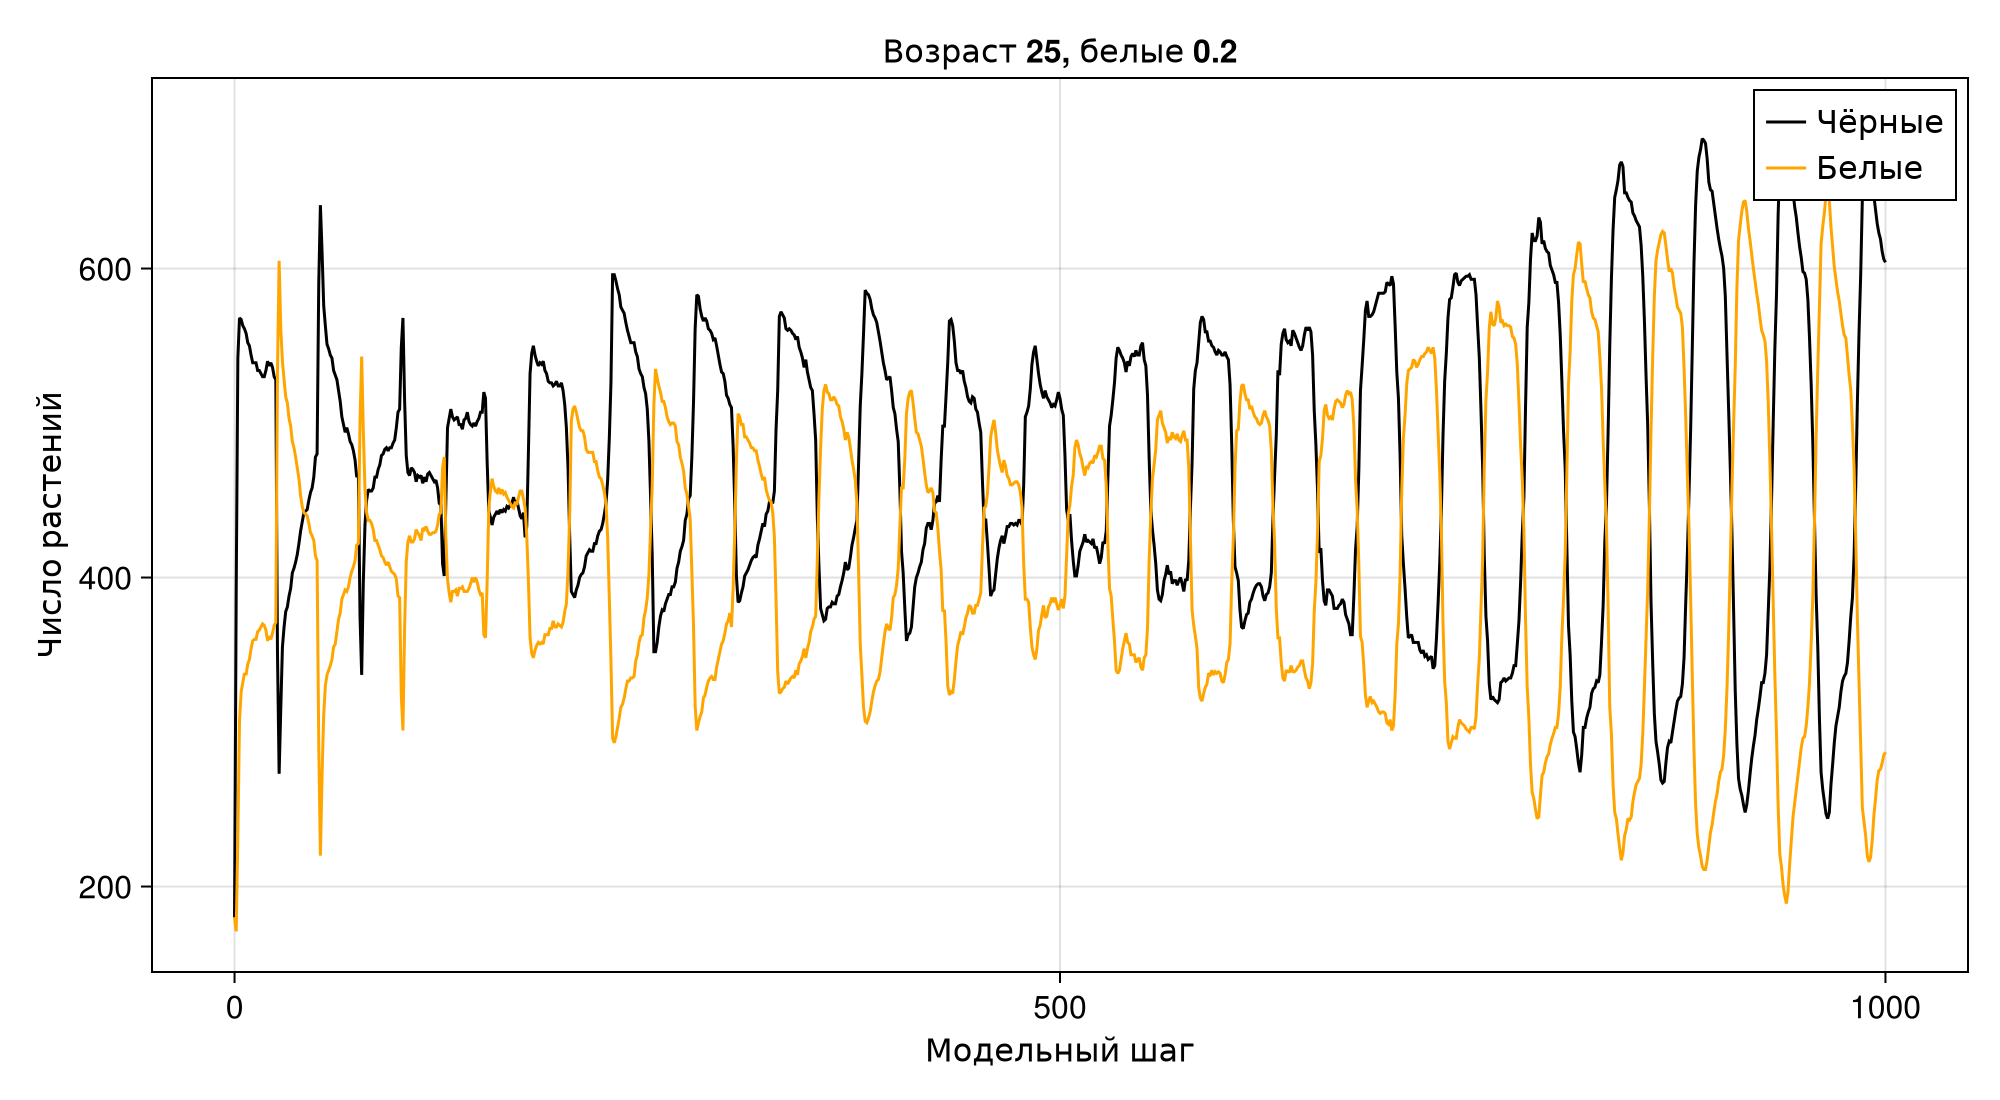

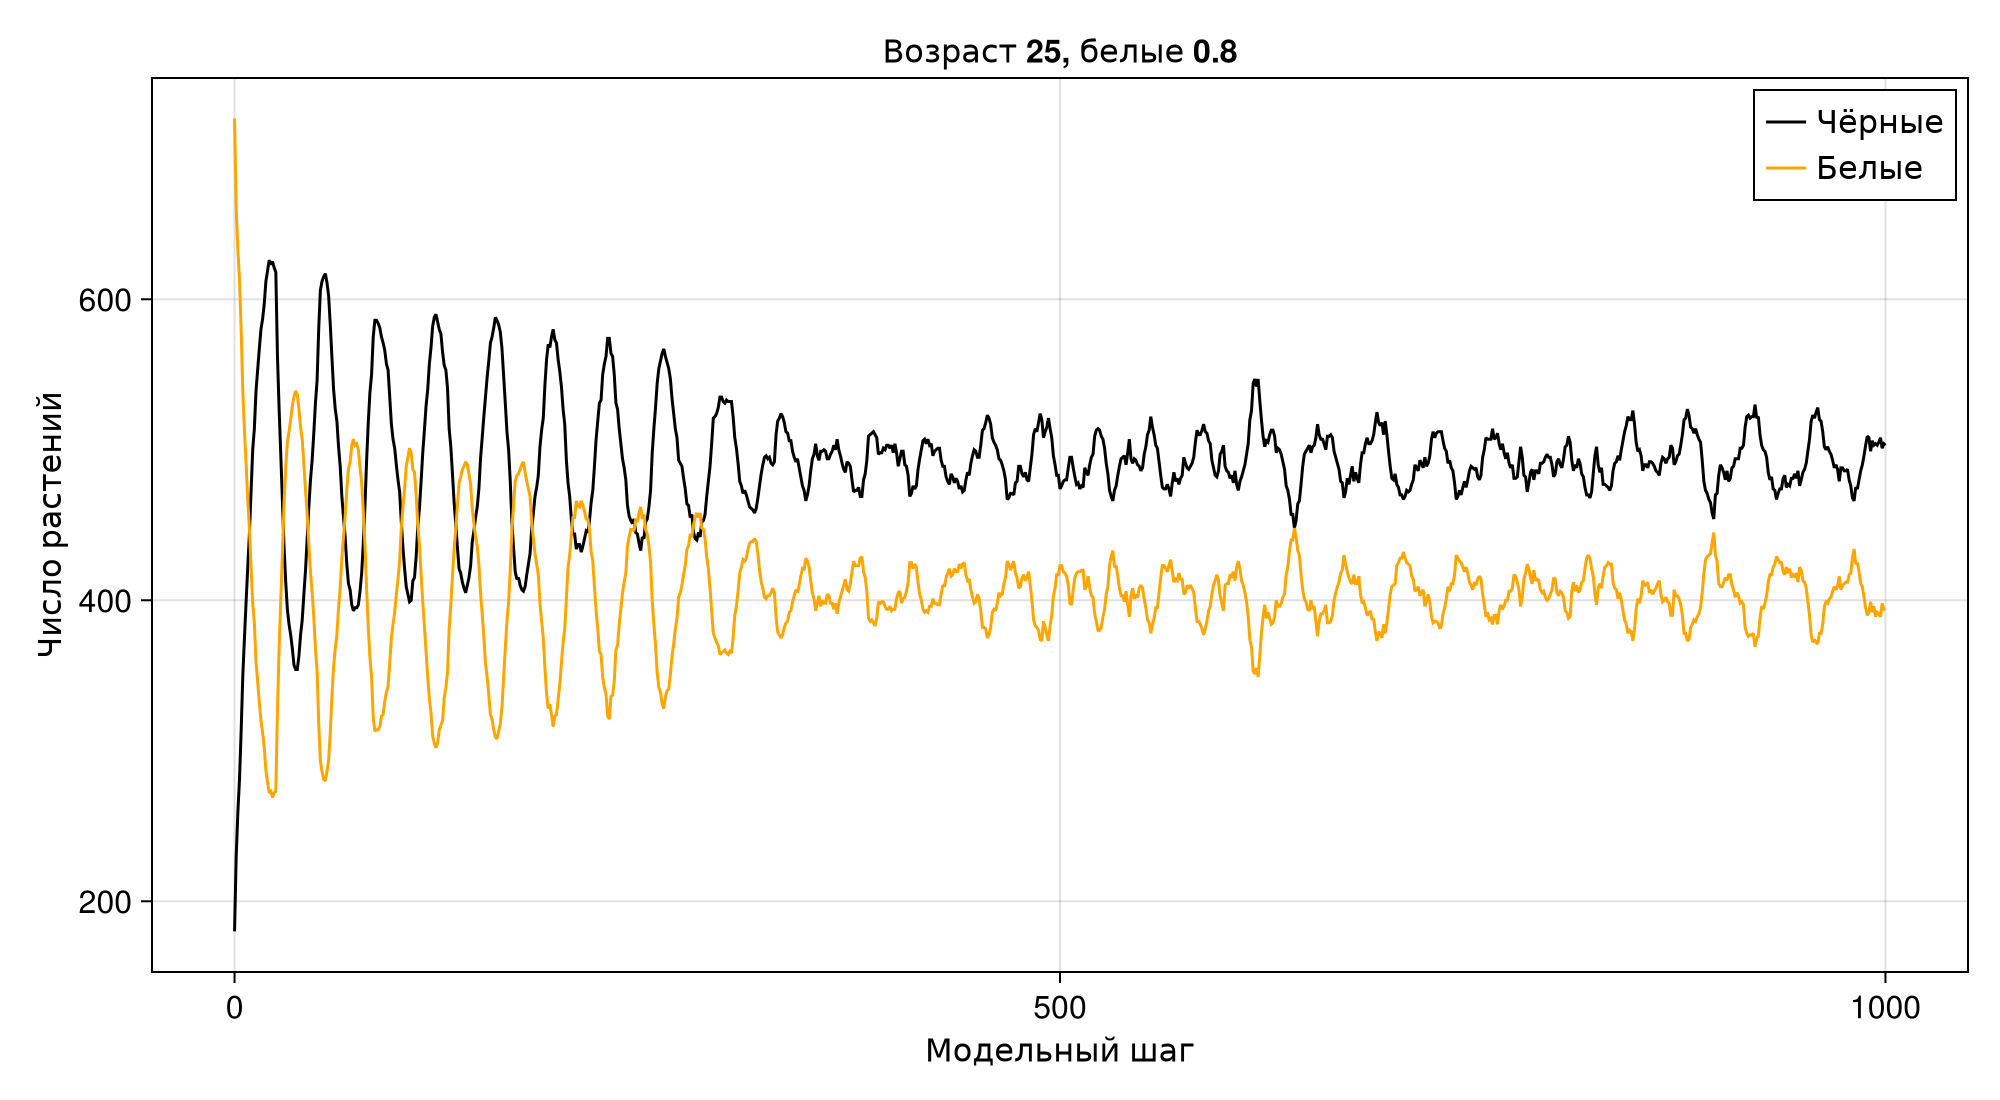

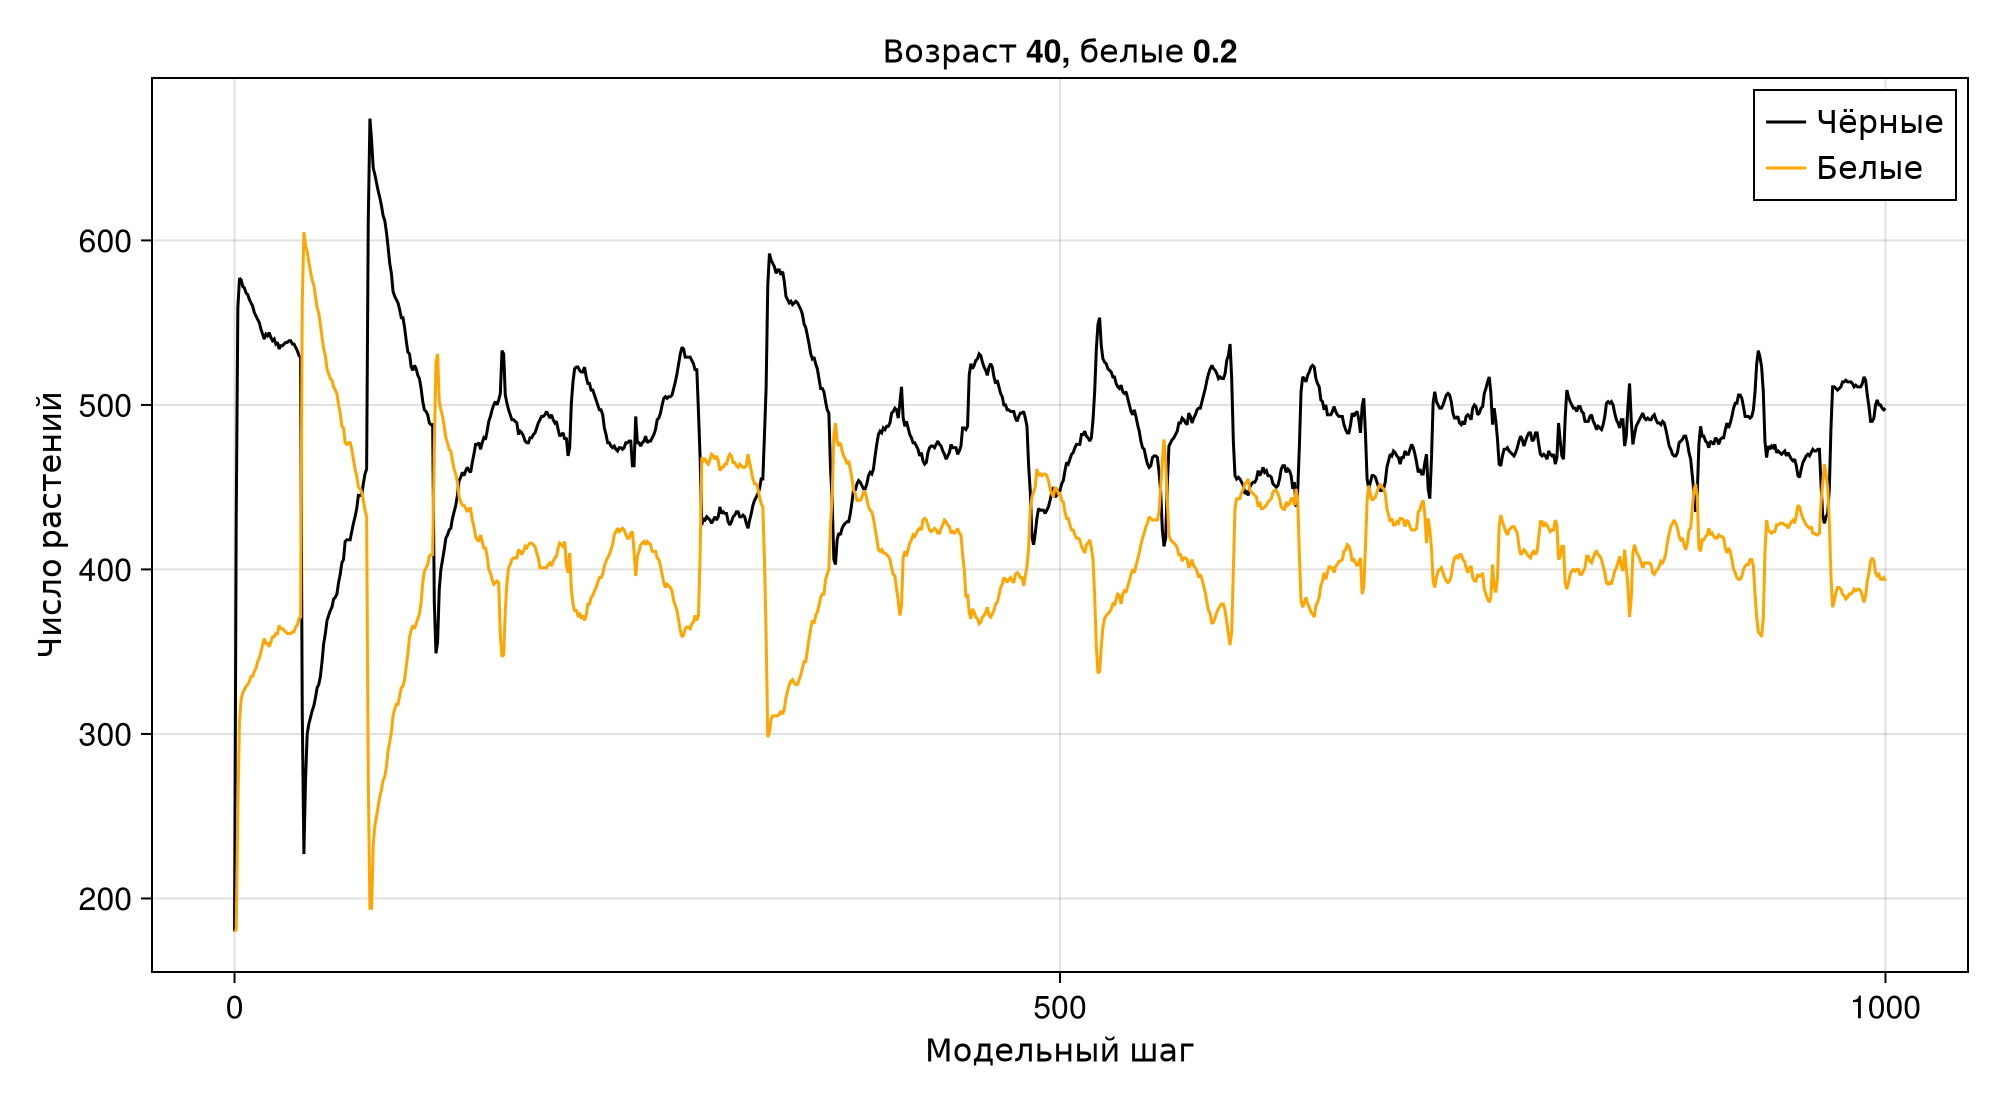

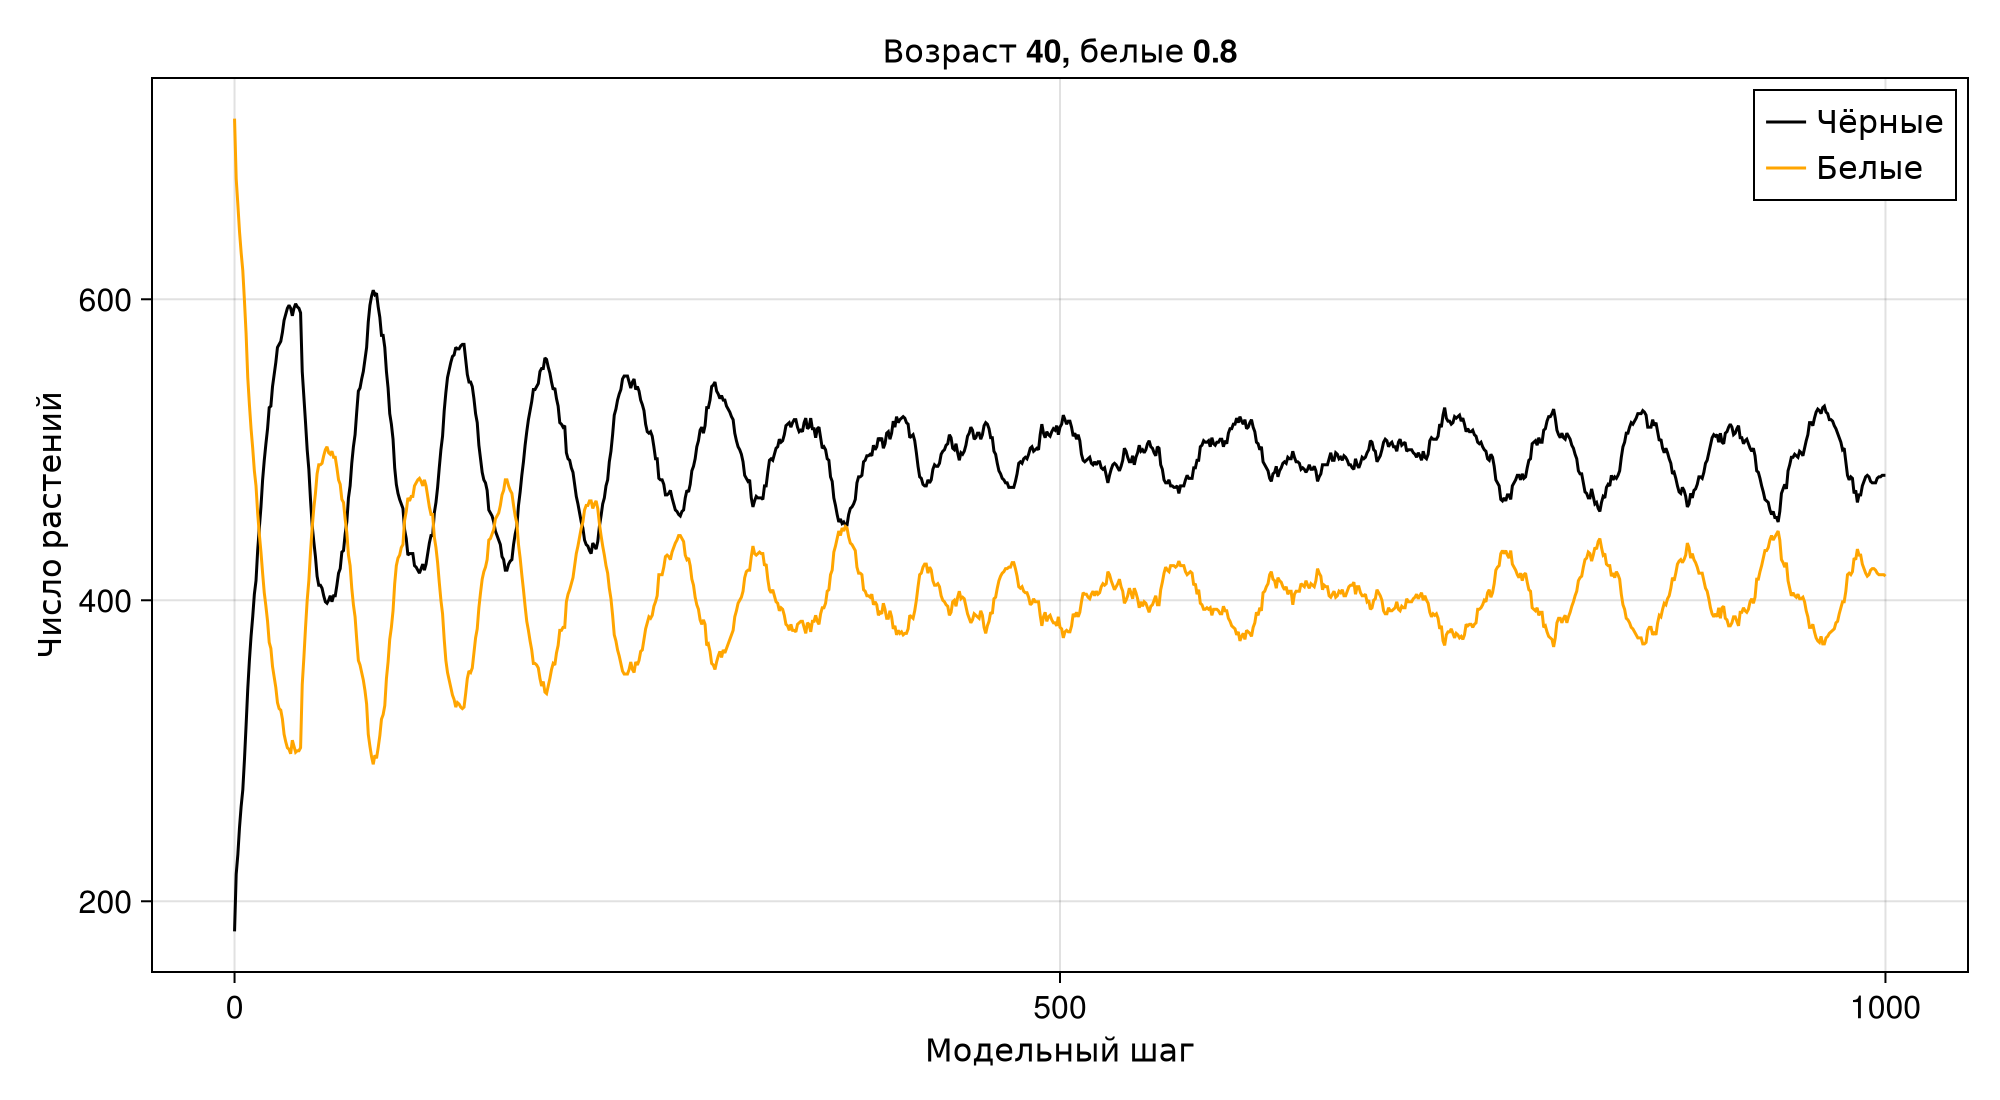

In [2]:
rows = NamedTuple[]
for (i, params) in enumerate(parameter_sets())
    model = daisyworld(; params...)
    df = history(model, 1000)
    CSV.write(
        datafile("daisyworld-count__param", "trajectory_$(i).csv"),
        df,
    )
    push!(
        rows,
        merge(
            (
                max_age = params[:max_age],
                init_white = params[:init_white],
            ),
            measure(model),
        ),
    )
    figure = countfigure(
        df;
        title = "Возраст $(params[:max_age]), белые $(params[:init_white])",
    )
    save(imagefile(lpad(17+i, 2, '0') * "-plot.png"), figure)
    display(figure)
end

## Итоговые значения

In [3]:
summary = DataFrame(rows)
CSV.write(datafile("daisyworld-count__param", "summary.csv"), summary)
summary

Row,max_age,init_white,time,black,white,temperature,luminosity,albedo
,Int64,Float64,Int64,Int64,Int64,Float64,Float64,Float64
1,25,0.2,1000,604,287,34.7542,1.0,0.410944
2,25,0.8,1000,503,394,24.8732,1.0,0.469389
3,40,0.2,1000,498,393,24.5054,1.0,0.469833
4,40,0.8,1000,483,416,22.6953,1.0,0.481278
